# Neural Network untuk Planar Dataset
## Pemodelan dengan Scikit-Learn (MLPClassifier) + Hyperparameter Tuning

Notebook ini membangun Neural Network untuk mengklasifikasikan flower/planar dataset (non-linearly separable).  
Topik yang dibahas:
1. Data Generation & Eksplorasi
2. Preprocessing
3. Baseline Model (Logistic Regression) — menunjukkan keterbatasan model linear
4. Neural Network (MLPClassifier)
5. Hyperparameter Tuning dengan GridSearchCV
6. Evaluasi Lengkap: Confusion Matrix, Accuracy, Balanced Accuracy, Precision, Recall, F1-Score, ROC-AUC, MAE, MSE, RMSE
7. Overfitting & Underfitting
8. Decision Boundary Visualization

## 1. Import Library

Kita menggunakan:
- NumPy & Pandas — manipulasi data
- Matplotlib & Seaborn — visualisasi
- Scikit-Learn — model ML, preprocessing, hyperparameter tuning, dan evaluasi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error
)

# Reproducibility
np.random.seed(42)

print('Semua library berhasil di-import!')
print(f'NumPy     : {np.__version__}')
print(f'Pandas    : {pd.__version__}')
import sklearn; print(f'Sklearn   : {sklearn.__version__}')

Semua library berhasil di-import!
NumPy     : 1.26.2
Pandas    : 2.1.4
Sklearn   : 1.6.1


---

## 2. Membuat Dataset (Planar / Flower Dataset)

Dataset berbentuk bunga (flower) ini bersifat non-linearly separable — tidak bisa dipisahkan dengan satu garis lurus.  
Hal ini menjadikannya kasus yang ideal untuk mendemonstrasikan kekuatan Neural Network dibandingkan model linear seperti Logistic Regression.

Komposisi dataset:
- `m = 400` sampel total
- `200` sampel per kelas (kelas 0 dan kelas 1)
- 2 fitur input: `X1` dan `X2` (koordinat 2D)
- 1 label output biner: `Y` ∈ {0, 1}

Data dihasilkan menggunakan fungsi `sin` pada sudut polar dengan noise Gaussian, sehingga menghasilkan pola spiral/bunga.

In [2]:
def planar_dataset():
    np.random.seed(1)
    m = 400
    N = m // 2
    X = np.zeros((m, 2))
    Y = np.zeros((m, 1))
    a = 4
    for j in range(2):
        ix = range(N  j, N  (j + 1))
        t = np.linspace(j  3.12, (j + 1)  3.12, N) + np.random.normal(0, 0.2, N)
        r = a  np.sin(4  t) + np.random.normal(0, 0.2, N)
        X[ix, 0] = r  np.sin(t)
        X[ix, 1] = r  np.cos(t)
        Y[ix] = j
    df = pd.DataFrame(np.column_stack((X, Y)), columns=['X1', 'X2', 'Y'])
    return df

df = planar_dataset()
print('Shape dataset:', df.shape)
print('\n5 baris pertama:')
df.head()

Shape dataset: (400, 3)

5 baris pertama:


,X1,X2,Y
0,1.204442,3.576114,0.0
1,0.158710,-1.482171,0.0
2,0.095247,-1.279955,0.0
3,0.349178,-2.064380,0.0
4,0.694150,2.889109,0.0


---

## 3. Eksplorasi Data (EDA)

Sebelum membangun model, kita perlu memahami:
- Distribusi kelas: apakah data seimbang?
- Sebaran fitur: apakah ada outlier?
- Visualisasi scatter plot: memperlihatkan pola non-linear

In [3]:
print('=== Statistik Deskriptif ===')
print(df.describe())
print()
print('=== Distribusi Kelas ===')
print(df['Y'].value_counts())
print(f'\nClass balance: {df["Y"].value_counts(normalize=True).round(3).to_dict()}')

=== Statistik Deskriptif ===
               X1          X2           Y
count  400.000000  400.000000  400.000000
mean    -0.043346    0.068566    0.500000
std      1.969950    2.006101    0.500626
min     -4.211898   -4.035124    0.000000
25%     -1.429345   -1.392949    0.000000
50%     -0.038972   -0.001496    0.500000
75%      1.474343    1.599116    1.000000
max      4.078166    4.037643    1.000000

=== Distribusi Kelas ===
Y
0.0    200
1.0    200
Name: count, dtype: int64

Class balance: {0.0: 0.5, 1.0: 0.5}


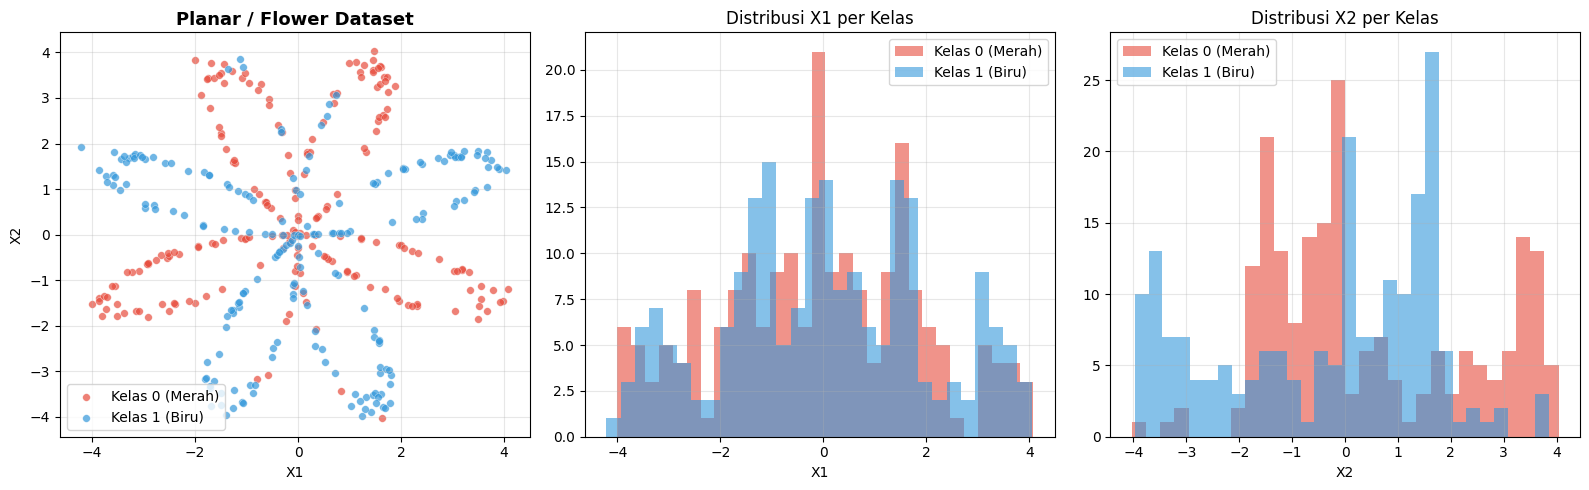

Catatan: Scatter plot memperlihatkan pola BUNGA/SPIRAL — tidak bisa dipisahkan dengan garis lurus!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {0.0: '#E74C3C', 1.0: '#3498DB'}
labels = {0.0: 'Kelas 0 (Merah)', 1.0: 'Kelas 1 (Biru)'}

# Scatter plot
ax = axes[0]
for cls in [0.0, 1.0]:
    mask = df['Y'] == cls
    ax.scatter(df.loc[mask, 'X1'], df.loc[mask, 'X2'],
               c=colors[cls], label=labels[cls], alpha=0.7, s=30, edgecolors='white', lw=0.3)
ax.set_title('Planar / Flower Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.legend(); ax.grid(True, alpha=0.3)

# Distribusi X1
ax = axes[1]
for cls in [0.0, 1.0]:
    mask = df['Y'] == cls
    ax.hist(df.loc[mask, 'X1'], bins=30, alpha=0.6, color=colors[cls], label=labels[cls])
ax.set_title('Distribusi X1 per Kelas'); ax.set_xlabel('X1'); ax.legend(); ax.grid(True, alpha=0.3)

# Distribusi X2
ax = axes[2]
for cls in [0.0, 1.0]:
    mask = df['Y'] == cls
    ax.hist(df.loc[mask, 'X2'], bins=30, alpha=0.6, color=colors[cls], label=labels[cls])
ax.set_title('Distribusi X2 per Kelas'); ax.set_xlabel('X2'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Catatan: Scatter plot memperlihatkan pola BUNGA/SPIRAL — tidak bisa dipisahkan dengan garis lurus!')

---

## 4. Preprocessing Data

Tahapan preprocessing meliputi:
1. Pemisahan fitur dan label — `X` (fitur) dan `y` (label)
2. Train-Test Split — 80% training, 20% testing
3. Feature Scaling (StandardScaler) — normalisasi fitur agar mean=0 dan std=1

> ⚠️ Penting: StandardScaler di-fit hanya pada data training, lalu di-transform pada data training dan testing. Ini mencegah data leakage dari test set ke training.

In [5]:
X = df[['X1', 'X2']].values
y = df['Y'].values.astype(int).ravel()

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform pada training
X_test_scaled  = scaler.transform(X_test)        # transform saja pada testing

print('=== Ringkasan Split ===')
print(f'Total data       : {len(X)}')
print(f'Training set     : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)100:.0f}%)')
print(f'Test set         : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)100:.0f}%)')
print(f'\nDistribusi kelas training : {np.bincount(y_train)}')
print(f'Distribusi kelas testing  : {np.bincount(y_test)}')
print(f'\nMean X_train setelah scaling: {X_train_scaled.mean(axis=0).round(4)}')
print(f'Std  X_train setelah scaling: {X_train_scaled.std(axis=0).round(4)}')

=== Ringkasan Split ===
Total data       : 400
Training set     : 320 sampel (80%)
Test set         : 80 sampel (20%)

Distribusi kelas training : [160 160]
Distribusi kelas testing  : [40 40]

Mean X_train setelah scaling: [ 0. -0.]
Std  X_train setelah scaling: [1. 1.]


---

## 5. Baseline: Logistic Regression (Model Linear)

Sebelum membangun Neural Network, kita coba Logistic Regression sebagai baseline.  
Model ini hanya mampu membuat decision boundary berupa garis lurus (hyperplane), sehingga akan gagal menangkap pola non-linear pada dataset bunga ini.

Ini akan menjadi pembanding untuk menunjukkan keunggulan Neural Network.

In [6]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_acc    = accuracy_score(y_test, y_pred_lr)
lr_f1     = f1_score(y_test, y_pred_lr)
lr_roc    = roc_auc_score(y_test, y_prob_lr)

print('=== Logistic Regression (Baseline) ===')
print(f'Accuracy  : {lr_acc:.4f}')
print(f'F1-Score  : {lr_f1:.4f}')
print(f'ROC-AUC   : {lr_roc:.4f}')
print()
print('Performa yang rendah membuktikan bahwa model linear TIDAK CUKUP untuk data non-linear.')

=== Logistic Regression (Baseline) ===
Accuracy  : 0.4000
F1-Score  : 0.4286
ROC-AUC   : 0.4931

Performa yang rendah membuktikan bahwa model linear TIDAK CUKUP untuk data non-linear.


---

## 6. Neural Network — MLPClassifier (Sklearn)

MLPClassifier (Multi-Layer Perceptron) adalah implementasi Neural Network di Scikit-Learn.  

Arsitektur yang digunakan:
- Input layer: 2 neuron (X1, X2)
- Hidden layer 1: 10 neuron, aktivasi ReLU
- Hidden layer 2: 5 neuron, aktivasi ReLU
- Output layer: 1 neuron (sigmoid → biner)

Hyperparameter penting:
- `hidden_layer_sizes` — jumlah dan ukuran hidden layer
- `activation` — fungsi aktivasi (relu, tanh, logistic)
- `alpha` — regularisasi L2 (untuk mencegah overfitting)
- `learning_rate_init` — learning rate awal
- `max_iter` — jumlah epoch maksimum

In [7]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(10, 5),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    verbose=False
)

nn_model.fit(X_train_scaled, y_train)

y_pred_nn = nn_model.predict(X_test_scaled)
y_prob_nn = nn_model.predict_proba(X_test_scaled)[:, 1]

print('=== Neural Network (MLP) — Model Awal ===')
print(f'Arsitektur     : Input(2) → Hidden({nn_model.hidden_layer_sizes}) → Output(1)')
print(f'Jumlah layer   : {nn_model.n_layers_}')
print(f'Iterasi (epoch): {nn_model.n_iter_}')
print(f'Loss akhir     : {nn_model.loss_:.6f}')
print()
print(f'Accuracy  : {accuracy_score(y_test, y_pred_nn):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_nn):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob_nn):.4f}')

=== Neural Network (MLP) — Model Awal ===
Arsitektur     : Input(2) → Hidden((10, 5)) → Output(1)
Jumlah layer   : 4
Iterasi (epoch): 500
Loss akhir     : 0.504542

Accuracy  : 0.7000
F1-Score  : 0.6757
ROC-AUC   : 0.7459


---

## 7. Hyperparameter Tuning dengan GridSearchCV

GridSearchCV secara sistematis mencoba semua kombinasi hyperparameter yang kita tentukan dan memilih yang terbaik.

Cara kerja:
1. Tentukan grid (kumpulan nilai) untuk setiap hyperparameter
2. GridSearchCV melatih model untuk setiap kombinasi menggunakan k-fold cross-validation (di sini `cv=5`)
3. Model terbaik dipilih berdasarkan metrik yang ditentukan (di sini `scoring='f1'`)

Cross-Validation (CV=5):  
Data training dibagi menjadi 5 fold. Model dilatih 5 kali — setiap kali menggunakan 4 fold untuk training dan 1 fold untuk validasi. Hasil rata-rata dari 5 percobaan menjadi skor final.

> ⏱️ Proses ini mungkin membutuhkan waktu beberapa menit tergantung ukuran grid.

In [8]:
param_grid = {
    'hidden_layer_sizes': [(8,), (16,), (10, 5), (16, 8)],
    'activation'        : ['relu', 'tanh'],
    'alpha'             : [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
}

base_nn = MLPClassifier(solver='adam', max_iter=500, random_state=42)

grid_search = GridSearchCV(
    estimator=base_nn,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print('\n=== Hasil GridSearchCV ===')
print(f'Jumlah kombinasi : {len(grid_search.cv_results_["params"])}')
print(f'Best CV F1-Score : {grid_search.best_score_:.4f}')
print(f'Best Parameters  :')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== Hasil GridSearchCV ===
Jumlah kombinasi : 48
Best CV F1-Score : 0.8770
Best Parameters  :
  activation: tanh
  alpha: 0.01
  hidden_layer_sizes: (10, 5)
  learning_rate_init: 0.01


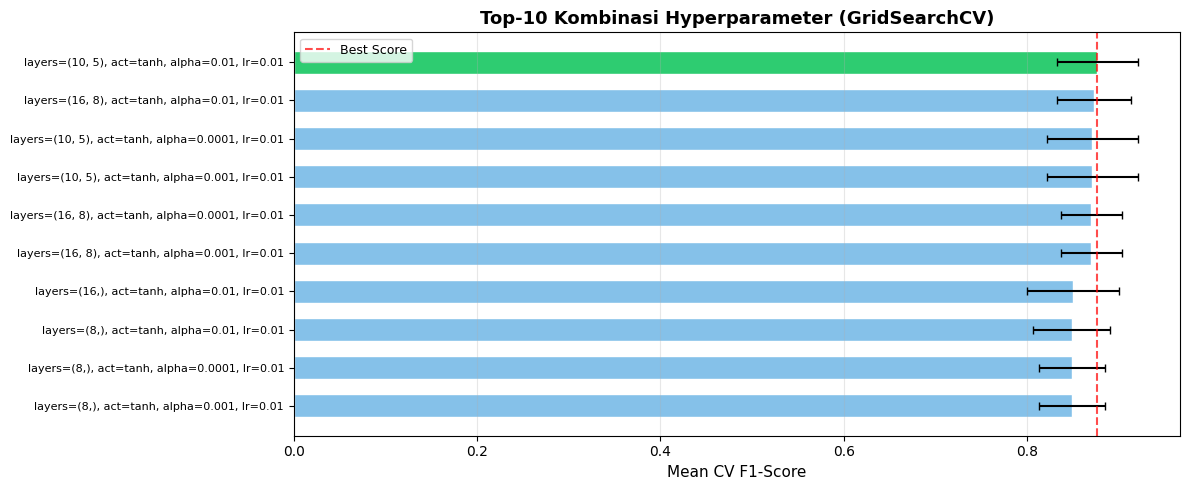

In [9]:
# Visualisasi top-10 kombinasi hyperparameter
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.nlargest(10, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']].reset_index(drop=True)
top10['params_str'] = top10['params'].apply(lambda p: f"layers={p['hidden_layer_sizes']}, act={p['activation']}, alpha={p['alpha']}, lr={p['learning_rate_init']}")

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ['#2ECC71' if i == 0 else '#85C1E9' for i in range(len(top10))]
bars = ax.barh(range(len(top10)), top10['mean_test_score'], xerr=top10['std_test_score'],
               color=colors_bar, edgecolor='white', height=0.6, capsize=3)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['params_str'], fontsize=8)
ax.set_xlabel('Mean CV F1-Score', fontsize=11)
ax.set_title('Top-10 Kombinasi Hyperparameter (GridSearchCV)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.axvline(top10['mean_test_score'].max(), color='red', linestyle='--', alpha=0.7, label='Best Score')
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('gridsearch_results.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 8. Model Terbaik (Best Estimator)

Setelah GridSearchCV menemukan kombinasi hyperparameter terbaik, kita ambil best estimator dan evaluasi pada test set (data yang belum pernah dilihat model).

In [10]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print('=== Model Terbaik setelah GridSearchCV ===')
print(f'Arsitektur hidden layer : {best_model.hidden_layer_sizes}')
print(f'Fungsi Aktivasi         : {best_model.activation}')
print(f'Regularisasi (alpha)    : {best_model.alpha}')
print(f'Learning Rate Init      : {best_model.learning_rate_init}')

=== Model Terbaik setelah GridSearchCV ===
Arsitektur hidden layer : (10, 5)
Fungsi Aktivasi         : tanh
Regularisasi (alpha)    : 0.01
Learning Rate Init      : 0.01


---

## 9. Evaluasi Model — Confusion Matrix

Confusion Matrix merangkum hasil prediksi model dalam bentuk tabel 2x2:

| . | Prediksi Positif (1) | Prediksi Negatif (0) |
|---|---|---|
| Aktual Positif (1) | TP (True Positive) | FN (False Negative) |
| Aktual Negatif (0) | FP (False Positive) | TN (True Negative) |

- TP (True Positive): Prediksi = 1, Aktual = 1 ✅
- TN (True Negative): Prediksi = 0, Aktual = 0 ✅
- FP (False Positive) / Type I Error: Prediksi = 1, Aktual = 0 ❌
- FN (False Negative) / Type II Error: Prediksi = 0, Aktual = 1 ❌

=== Confusion Matrix ===
True Positive  (TP): 38  → Benar prediksi Kelas 1
True Negative  (TN): 34  → Benar prediksi Kelas 0
False Positive (FP): 6  → Salah prediksi Kelas 0 sebagai Kelas 1 (Type I Error)
False Negative (FN): 2  → Salah prediksi Kelas 1 sebagai Kelas 0 (Type II Error)


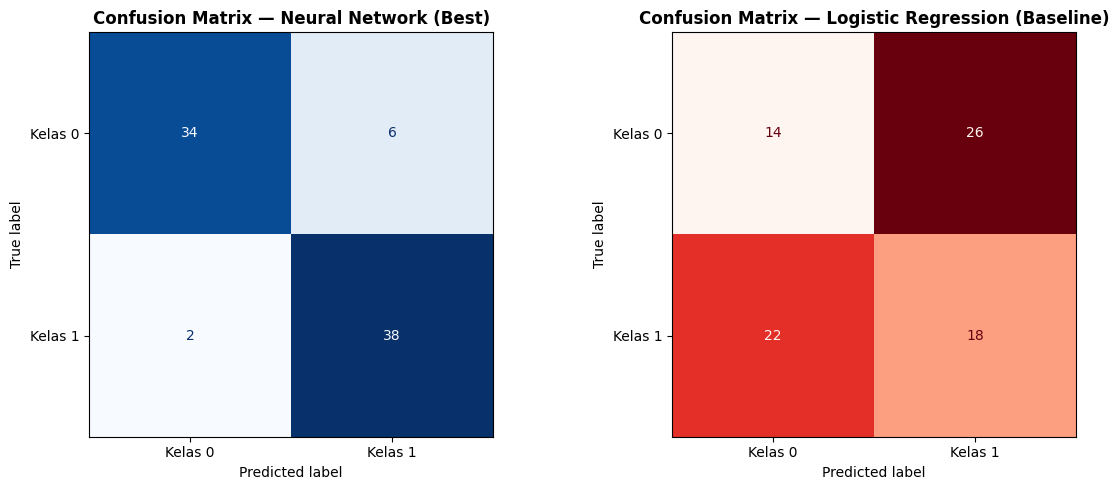

In [11]:
cm = confusion_matrix(y_test, y_pred_best)
TN, FP, FN, TP = cm.ravel()

print('=== Confusion Matrix ===')
print(f'True Positive  (TP): {TP}  → Benar prediksi Kelas 1')
print(f'True Negative  (TN): {TN}  → Benar prediksi Kelas 0')
print(f'False Positive (FP): {FP}  → Salah prediksi Kelas 0 sebagai Kelas 1 (Type I Error)')
print(f'False Negative (FN): {FN}  → Salah prediksi Kelas 1 sebagai Kelas 0 (Type II Error)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix — NN
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Kelas 0', 'Kelas 1'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Neural Network (Best)', fontsize=12, fontweight='bold')

# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Kelas 0', 'Kelas 1'])
disp_lr.plot(ax=axes[1], colorbar=False, cmap='Reds')
axes[1].set_title('Confusion Matrix — Logistic Regression (Baseline)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 10. Metrik Evaluasi Lengkap

### Metrik Klasifikasi

| Metrik | Rumus | Interpretasi |
|---|---|---|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | Proporsi prediksi benar secara keseluruhan |
| Balanced Accuracy | (Sensitivity + Specificity) / 2 | Accuracy yang disesuaikan untuk kelas tidak seimbang |
| Precision | TP/(TP+FP) | Dari yang diprediksi positif, berapa yang benar-benar positif? |
| Recall (Sensitivity) | TP/(TP+FN) | Dari yang aktual positif, berapa yang berhasil terdeteksi? |
| F1-Score | 2×(P×R)/(P+R) | Harmonic mean dari Precision dan Recall |
| ROC-AUC | Area under ROC curve | Kemampuan model membedakan kedua kelas (0.5 = random, 1.0 = sempurna) |

### Metrik Regresi (diterapkan pada probabilitas)

Meskipun ini adalah masalah klasifikasi, kita juga dapat menghitung metrik regresi menggunakan probabilitas prediksi (bukan label biner):
- MAE — Mean Absolute Error
- MSE — Mean Squared Error  
- RMSE — Root Mean Squared Error

In [12]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    acc        = accuracy_score(y_true, y_pred)
    bal_acc    = balanced_accuracy_score(y_true, y_pred)
    prec       = precision_score(y_true, y_pred)
    rec        = recall_score(y_true, y_pred)
    f1         = f1_score(y_true, y_pred)
    roc_auc    = roc_auc_score(y_true, y_prob)
    mae        = mean_absolute_error(y_true, y_prob)
    mse        = mean_squared_error(y_true, y_prob)
    rmse       = np.sqrt(mse)
    
    print(f'\n{'='45}')
    print(f'  {model_name}')
    print(f'{'='45}')
    print(f'  [Klasifikasi]')
    print(f'  Accuracy          : {acc:.4f}  ({acc100:.2f}%)')
    print(f'  Balanced Accuracy : {bal_acc:.4f}')
    print(f'  Precision         : {prec:.4f}')
    print(f'  Recall            : {rec:.4f}')
    print(f'  F1-Score          : {f1:.4f}')
    print(f'  ROC-AUC           : {roc_auc:.4f}')
    print(f'  [Regresi pada Probabilitas]')
    print(f'  MAE               : {mae:.4f}')
    print(f'  MSE               : {mse:.4f}')
    print(f'  RMSE              : {rmse:.4f}')
    
    return dict(Model=model_name, Accuracy=acc, Balanced_Accuracy=bal_acc,
                Precision=prec, Recall=rec, F1=f1, ROC_AUC=roc_auc,
                MAE=mae, MSE=mse, RMSE=rmse)

res_lr   = evaluate_model(y_test, y_pred_lr,   y_prob_lr,   'Logistic Regression (Baseline)')
res_nn   = evaluate_model(y_test, y_pred_nn,   y_prob_nn,   'Neural Network (Awal)')
res_best = evaluate_model(y_test, y_pred_best, y_prob_best, 'Neural Network (Best - GridSearch)')


  Logistic Regression (Baseline)
  [Klasifikasi]
  Accuracy          : 0.4000  (40.00%)
  Balanced Accuracy : 0.4000
  Precision         : 0.4091
  Recall            : 0.4500
  F1-Score          : 0.4286
  ROC-AUC           : 0.4931
  [Regresi pada Probabilitas]
  MAE               : 0.4950
  MSE               : 0.2550
  RMSE              : 0.5049

  Neural Network (Awal)
  [Klasifikasi]
  Accuracy          : 0.7000  (70.00%)
  Balanced Accuracy : 0.7000
  Precision         : 0.7353
  Recall            : 0.6250
  F1-Score          : 0.6757
  ROC-AUC           : 0.7459
  [Regresi pada Probabilitas]
  MAE               : 0.4023
  MSE               : 0.2005
  RMSE              : 0.4477

  Neural Network (Best - GridSearch)
  [Klasifikasi]
  Accuracy          : 0.9000  (90.00%)
  Balanced Accuracy : 0.9000
  Precision         : 0.8636
  Recall            : 0.9500
  F1-Score          : 0.9048
  ROC-AUC           : 0.9600
  [Regresi pada Probabilitas]
  MAE               : 0.1492
  MSE     

In [13]:
# Tabel perbandingan semua model
results_df = pd.DataFrame([res_lr, res_nn, res_best])
results_df = results_df.set_index('Model').round(4)

print('\n=== Tabel Perbandingan Model ===')
results_df


=== Tabel Perbandingan Model ===


,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,MAE,MSE,RMSE
Model,,,,,,,,,
Logistic Regression (Baseline),0.4,0.4,0.4091,0.450,0.4286,0.4931,0.4950,0.2550,0.5049
Neural Network (Awal),0.7,0.7,0.7353,0.625,0.6757,0.7459,0.4023,0.2005,0.4477
Neural Network (Best - GridSearch),0.9,0.9,0.8636,0.950,0.9048,0.9600,0.1492,0.0790,0.2810


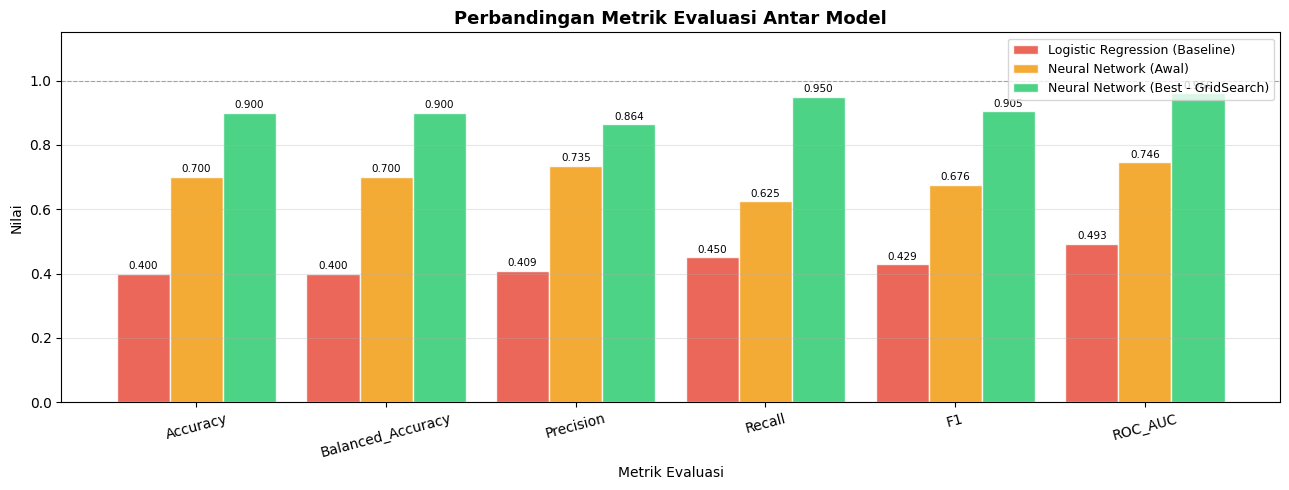

In [14]:
# Visualisasi perbandingan metrik
metrics = ['Accuracy', 'Balanced_Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x = np.arange(len(metrics))
width = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
model_colors = ['#E74C3C', '#F39C12', '#2ECC71']

for i, (_, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i  width, [row[m] for m in metrics], width,
                  label=row.name, color=model_colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.008,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Metrik Evaluasi'); ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Metrik Evaluasi Antar Model', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, rotation=15)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axhline(1.0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 11. ROC Curve

ROC Curve (Receiver Operating Characteristic) adalah grafik yang menunjukkan trade-off antara:
- True Positive Rate (TPR / Recall) pada sumbu Y
- False Positive Rate (FPR) pada sumbu X

Interpretasi:
- Kurva yang lebih mendekati sudut kiri atas = model lebih baik
- AUC = 1.0 = model sempurna
- AUC = 0.5 = model random (tidak lebih baik dari menebak)
- AUC < 0.5 = model lebih buruk dari random

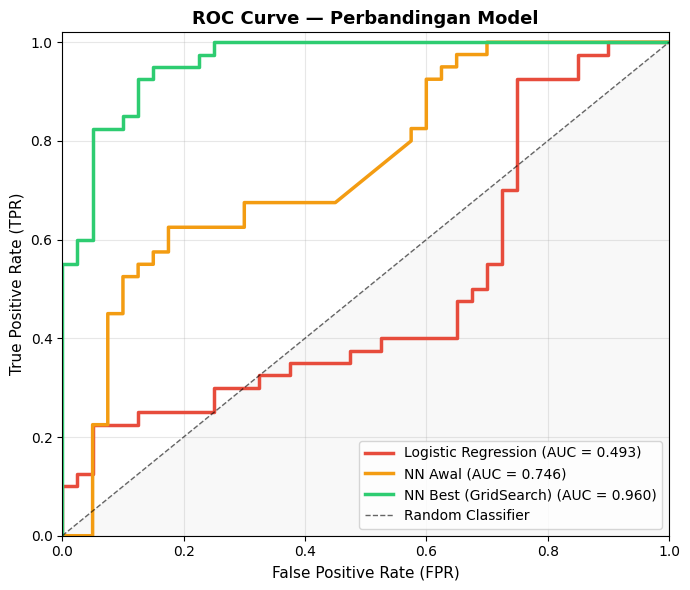

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))

models_roc = [
    ('Logistic Regression', y_prob_lr,   '#E74C3C'),
    ('NN Awal',             y_prob_nn,   '#F39C12'),
    ('NN Best (GridSearch)',y_prob_best, '#2ECC71'),
]

for name, prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC Curve — Perbandingan Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 12. Overfitting dan Underfitting

Overfitting terjadi ketika model terlalu kompleks — model "menghafal" data training hingga performanya pada data baru (test set) jauh lebih buruk.

Underfitting terjadi ketika model terlalu sederhana — model tidak mampu menangkap pola yang ada bahkan pada data training.

Model yang baik (Good Fit) memiliki performa tinggi di keduanya, dengan gap yang kecil antara train dan test.

### 12.1 Deteksi dengan Learning Curve

Learning Curve memplot:
- Training score vs ukuran data training
- Validation score vs ukuran data training

Pola yang terbentuk:
- Underfitting: Kedua kurva rendah dan berdekatan
- Overfitting: Training tinggi, Validation rendah (gap besar)
- Good fit: Kedua kurva tinggi dan konvergen

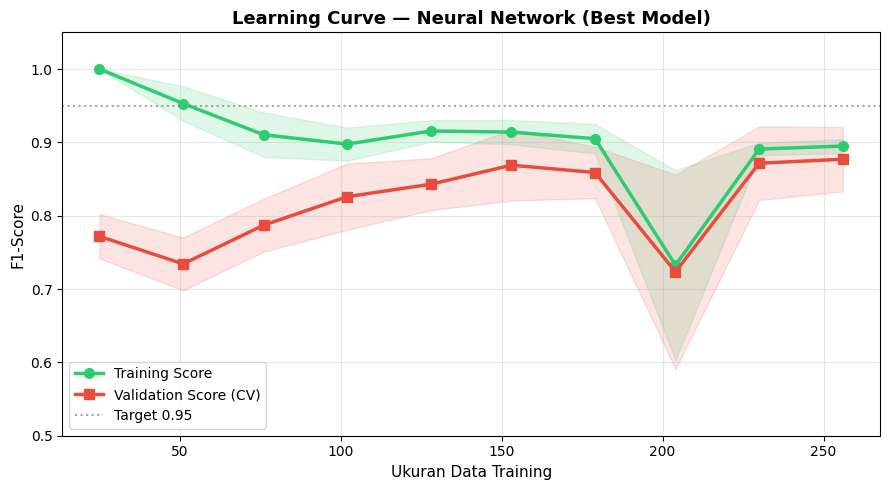

Training F1 (full data)   : 0.8949
Validation F1 (full data) : 0.8770
Gap (Train - Val)         : 0.0179
✅  Gap kecil dan Validation tinggi → Good Fit!


In [16]:
# Learning Curve untuk Best Model
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2ECC71', linewidth=2.5, label='Training Score', markersize=7)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2ECC71')
ax.plot(train_sizes, val_mean, 's-', color='#E74C3C', linewidth=2.5, label='Validation Score (CV)', markersize=7)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#E74C3C')

ax.axhline(y=0.95, color='gray', linestyle=':', alpha=0.7, label='Target 0.95')
ax.set_xlabel('Ukuran Data Training', fontsize=11)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Learning Curve — Neural Network (Best Model)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim([0.5, 1.05])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Training F1 (full data)   : {train_mean[-1]:.4f}')
print(f'Validation F1 (full data) : {val_mean[-1]:.4f}')
print(f'Gap (Train - Val)         : {gap:.4f}')
if gap > 0.1:
    print('⚠️  Gap cukup besar → kemungkinan ada OVERFITTING')
elif val_mean[-1] < 0.7:
    print('⚠️  Validation rendah → kemungkinan UNDERFITTING')
else:
    print('✅  Gap kecil dan Validation tinggi → Good Fit!')

### 12.2 Simulasi Overfitting vs Underfitting

Kita akan membuat tiga model dengan kompleksitas berbeda:
- Underfitting: Arsitektur sangat kecil (2,) + max_iter rendah
- Good Fit: Best model dari GridSearchCV
- Overfitting: Arsitektur sangat besar (100, 100, 100) + alpha kecil

=== Perbandingan Overfitting / Underfitting ===
                            Model  Train Accuracy  Test Accuracy      Gap
Underfitting\n(Terlalu Sederhana)         0.52500         0.5375 -0.01250
           Good Fit\n(Best Model)         0.90625         0.9000  0.00625
  Overfitting\n(Terlalu Kompleks)         0.90000         0.8375  0.06250


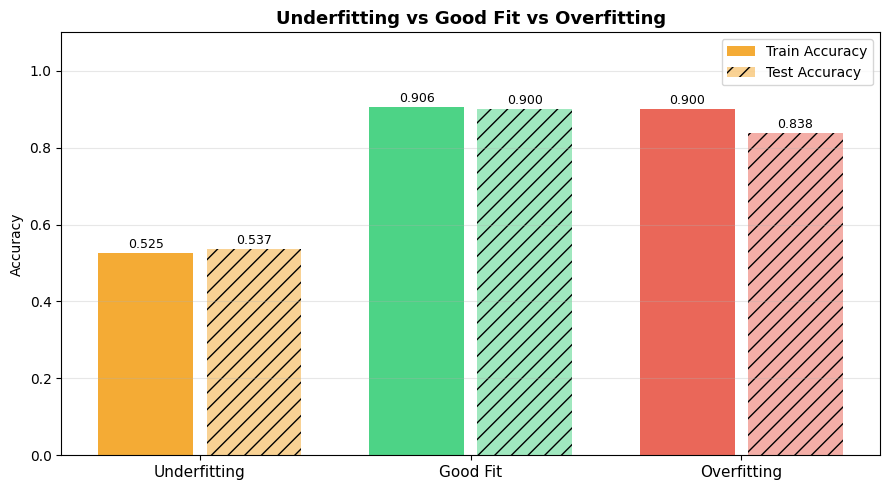

In [17]:
models_fit = {
    'Underfitting\n(Terlalu Sederhana)': MLPClassifier(
        hidden_layer_sizes=(2,), activation='relu', max_iter=20, random_state=42, alpha=0.1),
    'Good Fit\n(Best Model)': best_model,
    'Overfitting\n(Terlalu Kompleks)': MLPClassifier(
        hidden_layer_sizes=(100, 100, 100), activation='relu', max_iter=1000, random_state=42, alpha=0.000001),
}

fit_results = []
for name, model in models_fit.items():
    if name != 'Good Fit\n(Best Model)':
        model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_scaled))
    fit_results.append({'Model': name, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc, 'Gap': train_acc - test_acc})

fit_df = pd.DataFrame(fit_results)
print('=== Perbandingan Overfitting / Underfitting ===')
print(fit_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
short_names = [m.split('\n')[0] for m in fit_df['Model']]
b1 = ax.bar(x - 0.2, fit_df['Train Accuracy'], 0.35, label='Train Accuracy', color=['#F39C12','#2ECC71','#E74C3C'], alpha=0.85)
b2 = ax.bar(x + 0.2, fit_df['Test Accuracy'],  0.35, label='Test Accuracy',  color=['#F39C12','#2ECC71','#E74C3C'], alpha=0.45, hatch='//')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel('Accuracy'); ax.set_ylim([0, 1.1])
ax.set_title('Underfitting vs Good Fit vs Overfitting', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('overfit_underfit.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 13. Decision Boundary Visualization

Visualisasi decision boundary memperlihatkan secara intuitif bagaimana model memisahkan dua kelas dalam ruang fitur 2D.

Kita bandingkan keempat model:
1. Logistic Regression — garis lurus (tidak bisa menangkap pola non-linear)
2. NN Underfitting — batas sederhana
3. NN Best — batas yang sesuai dengan pola data
4. NN Overfitting — batas yang terlalu kompleks / berliku-liku

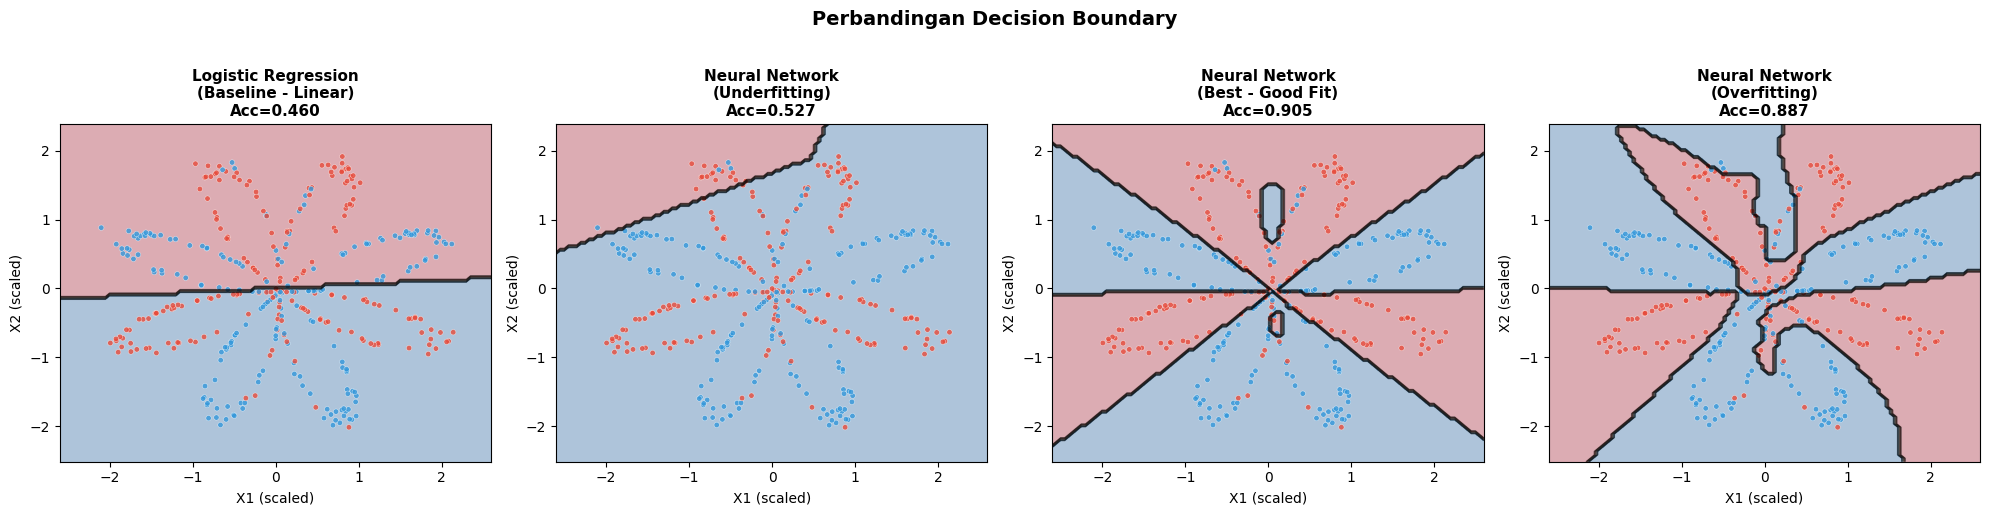

In [18]:
def plot_decision_boundary(model, X_scaled, y, ax, title, scaler_obj):
    h = 0.05
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='RdBu')
    ax.contour(xx, yy, Z, colors='black', linewidths=0.8, alpha=0.5)
    colors = ['#E74C3C' if label == 0 else '#3498DB' for label in y]
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, s=15, edgecolors='white', lw=0.3, alpha=0.8)
    acc = accuracy_score(y, model.predict(X_scaled))
    ax.set_title(f'{title}\nAcc={acc:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('X1 (scaled)'); ax.set_ylabel('X2 (scaled)')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

under_model  = models_fit['Underfitting\n(Terlalu Sederhana)']
over_model   = models_fit['Overfitting\n(Terlalu Kompleks)']

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
y_all        = np.concatenate([y_train, y_test])

plot_decision_boundary(lr_model,    X_all_scaled, y_all, axes[0], 'Logistic Regression\n(Baseline - Linear)', scaler)
plot_decision_boundary(under_model, X_all_scaled, y_all, axes[1], 'Neural Network\n(Underfitting)', scaler)
plot_decision_boundary(best_model,  X_all_scaled, y_all, axes[2], 'Neural Network\n(Best - Good Fit)', scaler)
plot_decision_boundary(over_model,  X_all_scaled, y_all, axes[3], 'Neural Network\n(Overfitting)', scaler)

plt.suptitle('Perbandingan Decision Boundary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 14. Loss Curve (Training Convergence)

MLPClassifier menyimpan nilai loss di setiap iterasi training melalui atribut `loss_curve_`.  
Grafik ini menunjukkan apakah model konvergen dengan baik:
- Idealnya, loss terus menurun hingga stabil
- Jika loss tidak turun = learning rate terlalu kecil atau model tidak mampu belajar
- Jika loss naik-turun = learning rate terlalu besar

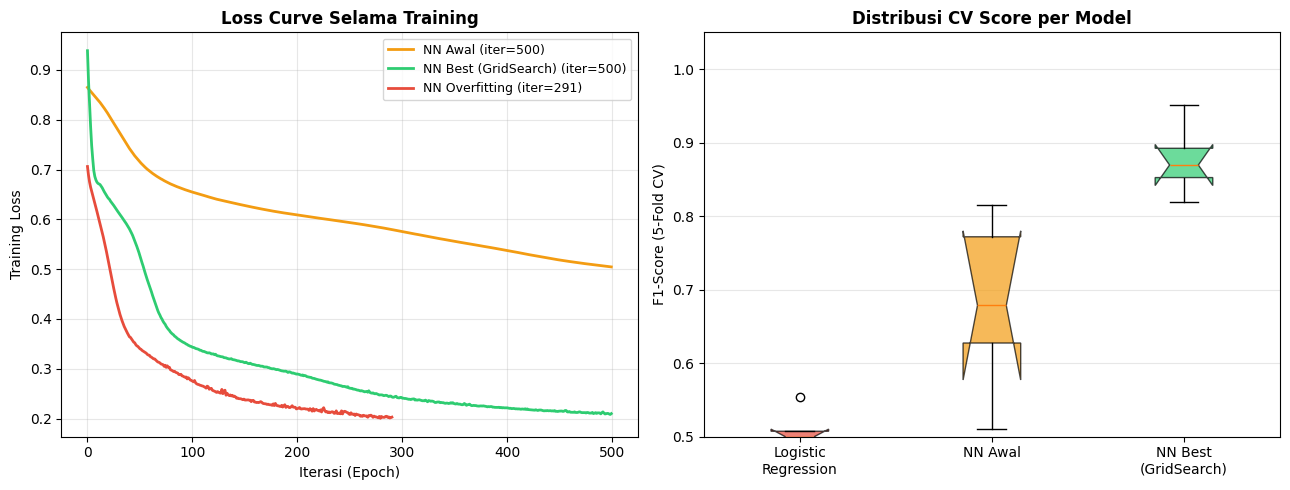

CV F1-Score (LR)       : 0.5049 ± 0.0274
CV F1-Score (NN Awal)  : 0.6807 ± 0.1078
CV F1-Score (NN Best)  : 0.8770 ± 0.0439


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model, color, label in [
    (nn_model,   '#F39C12', 'NN Awal'),
    (best_model, '#2ECC71', 'NN Best (GridSearch)'),
    (over_model, '#E74C3C', 'NN Overfitting'),
]:
    axes[0].plot(model.loss_curve_, color=color, linewidth=2, label=f'{label} (iter={model.n_iter_})')

axes[0].set_xlabel('Iterasi (Epoch)'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Loss Curve Selama Training', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Cross-validation scores
cv_scores_lr   = cross_val_score(lr_model,   X_train_scaled, y_train, cv=5, scoring='f1')
cv_scores_nn   = cross_val_score(nn_model,   X_train_scaled, y_train, cv=5, scoring='f1')
cv_scores_best = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1')

cv_data = [cv_scores_lr, cv_scores_nn, cv_scores_best]
cv_labels = ['Logistic\nRegression', 'NN Awal', 'NN Best\n(GridSearch)']
bp = axes[1].boxplot(cv_data, labels=cv_labels, patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], ['#E74C3C', '#F39C12', '#2ECC71']):
    patch.set_facecolor(color); patch.set_alpha(0.7)

axes[1].set_ylabel('F1-Score (5-Fold CV)'); axes[1].set_ylim([0.5, 1.05])
axes[1].set_title('Distribusi CV Score per Model', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('loss_and_cv.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'CV F1-Score (LR)       : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print(f'CV F1-Score (NN Awal)  : {cv_scores_nn.mean():.4f} ± {cv_scores_nn.std():.4f}')
print(f'CV F1-Score (NN Best)  : {cv_scores_best.mean():.4f} ± {cv_scores_best.std():.4f}')

---
## 15. Kesimpulan dan Ringkasan

Berikut adalah ringkasan temuan utama dari notebook ini:

In [20]:
print('='  60)
print('       KESIMPULAN PEMODELAN NEURAL NETWORK')
print('       Planar / Flower Dataset')
print('='  60)

print()
print('📌 1. DATASET')
print('   - 400 sampel, 2 fitur (X1, X2), 2 kelas seimbang')
print('   - Pola NON-LINEAR (spiral/bunga) → linear model gagal')

print()
print('📌 2. PERBANDINGAN MODEL (Test Set)')
print(f'   - Logistic Regression  : Acc = {res_lr["Accuracy"]:.4f}, F1 = {res_lr["F1"]:.4f}, AUC = {res_lr["ROC_AUC"]:.4f}')
print(f'   - Neural Network Awal  : Acc = {res_nn["Accuracy"]:.4f}, F1 = {res_nn["F1"]:.4f}, AUC = {res_nn["ROC_AUC"]:.4f}')
print(f'   - NN Best (GridSearch) : Acc = {res_best["Accuracy"]:.4f}, F1 = {res_best["F1"]:.4f}, AUC = {res_best["ROC_AUC"]:.4f}')

print()
print('📌 3. HYPERPARAMETER TERBAIK (GridSearchCV)')
for k, v in grid_search.best_params_.items():
    print(f'   - {k}: {v}')

print()
print('📌 4. OVERFITTING & UNDERFITTING')
print('   - Model terlalu sederhana → Underfitting (train & test rendah)')
print('   - Model terlalu kompleks  → Overfitting (train tinggi, test rendah)')
print('   - Best model              → Good Fit (train & test tinggi, gap kecil)')
print('   - Regularisasi (alpha) dan arsitektur yang tepat mencegah overfitting')

print()
print('📌 5. METRIK EVALUASI')
print('   - Accuracy         : proporsi prediksi benar keseluruhan')
print('   - Balanced Accuracy: cocok untuk data tidak seimbang')
print('   - Precision        : dari prediksi positif, berapa yang benar?')
print('   - Recall           : dari aktual positif, berapa yang tertangkap?')
print('   - F1-Score         : keseimbangan Precision dan Recall')
print('   - ROC-AUC          : kemampuan membedakan kelas (0.5–1.0)')
print('   - MAE/MSE/RMSE     : error pada probabilitas prediksi')

print()
print('✅ Neural Network berhasil mempelajari pola NON-LINEAR')
print('   yang tidak bisa ditangani oleh Logistic Regression!')
print('='  60)

       KESIMPULAN PEMODELAN NEURAL NETWORK
       Planar / Flower Dataset

📌 1. DATASET
   - 400 sampel, 2 fitur (X1, X2), 2 kelas seimbang
   - Pola NON-LINEAR (spiral/bunga) → linear model gagal

📌 2. PERBANDINGAN MODEL (Test Set)
   - Logistic Regression  : Acc = 0.4000, F1 = 0.4286, AUC = 0.4931
   - Neural Network Awal  : Acc = 0.7000, F1 = 0.6757, AUC = 0.7459
   - NN Best (GridSearch) : Acc = 0.9000, F1 = 0.9048, AUC = 0.9600

📌 3. HYPERPARAMETER TERBAIK (GridSearchCV)
   - activation: tanh
   - alpha: 0.01
   - hidden_layer_sizes: (10, 5)
   - learning_rate_init: 0.01

📌 4. OVERFITTING & UNDERFITTING
   - Model terlalu sederhana → Underfitting (train & test rendah)
   - Model terlalu kompleks  → Overfitting (train tinggi, test rendah)
   - Best model              → Good Fit (train & test tinggi, gap kecil)
   - Regularisasi (alpha) dan arsitektur yang tepat mencegah overfitting

📌 5. METRIK EVALUASI
   - Accuracy         : proporsi prediksi benar keseluruhan
   - Balanced Accur